In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=True)  # force reload

from langchain_groq import ChatGroq
model = ChatGroq(model="llama-3.1-8b-instant")

In [14]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str
    evaluation: str      # ← new
    final_blog: str 

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [15]:
def evaluate_blog(state: BlogState) -> BlogState:
    content = state['content']

    prompt = f"""Evaluate the following blog on these 4 parameters and give a score out of 10 for each:

    1. Grammar & Language Quality
    2. Structure & Flow (intro, body, conclusion)
    3. Content Depth & Accuracy
    4. SEO & Readability

    Also give:
    - Overall Score (out of 10)
    - Top 3 improvements needed
    - Improved version of the blog

    Blog:
    {content}
    """

    evaluation = model.invoke(prompt).content
    state['evaluation'] = evaluation
    return state

In [16]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog',evaluate_blog)
# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog','evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()

In [17]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '**Title:** "The Rise of AI in India: Shaping the Future of Technology and Society"\n\n**I. Introduction**\n\n* Brief overview of the growing importance of Artificial Intelligence (AI) globally\n* Contextualizing the rise of AI in India, including government initiatives and industry investments\n* Thesis statement: "AI in India is transforming the country\'s technology landscape, driving innovation, and creating new opportunities for economic growth and social impact."\n\n**II. History and Development of AI in India**\n\n* Early beginnings of AI research in India, including milestones and key players\n* Evolution of AI in India, including the role of government initiatives, industry partnerships, and academic research\n* Notable successes and achievements in AI research and development in India\n\n**III. Current Status of AI in India**\n\n* Overview of the current AI ecosystem in India, including key players, startups, and research institutio

In [18]:
print(final_state['outline'])

**Title:** "The Rise of AI in India: Shaping the Future of Technology and Society"

**I. Introduction**

* Brief overview of the growing importance of Artificial Intelligence (AI) globally
* Contextualizing the rise of AI in India, including government initiatives and industry investments
* Thesis statement: "AI in India is transforming the country's technology landscape, driving innovation, and creating new opportunities for economic growth and social impact."

**II. History and Development of AI in India**

* Early beginnings of AI research in India, including milestones and key players
* Evolution of AI in India, including the role of government initiatives, industry partnerships, and academic research
* Notable successes and achievements in AI research and development in India

**III. Current Status of AI in India**

* Overview of the current AI ecosystem in India, including key players, startups, and research institutions
* Analysis of the various AI applications and industries be

In [11]:
print(final_state['content'])

**The Rise of AI in India: Revolutionizing Industries and Transforming Lives**

**Introduction**

The rapidly growing AI market in India is transforming the nation's economic landscape, revolutionizing industries, and enhancing innovation. As the world becomes increasingly reliant on technology, AI is poised to play a crucial role in India's economic growth and development. The adoption of AI in various sectors, such as healthcare, finance, education, manufacturing, and transportation, is expected to create new business models, revenue streams, and job opportunities. In this blog, we will explore the current state of AI in India, its applications, benefits, challenges, and limitations, and provide an outlook for the future of AI in the country.

**II. Current State of AI in India**

India's AI ecosystem is rapidly expanding, with key players, startups, and research institutions driving innovation and adoption. The country has seen significant investments in AI research and development,

In [19]:
print("\n=== EVALUATION ===")
print(final_state['evaluation'])


=== EVALUATION ===
**Evaluation of the Blog**

**Parameter 1: Grammar & Language Quality**
Score: 8/10
The blog is well-written, and the language is clear and concise. However, there are a few grammatical errors and awkward phrasings, such as "driven by government initiatives, industry investments, and a growing talent pool of AI researchers and developers" (sentence 5). Additionally, some sentences are quite long and convoluted, which can make them difficult to follow.

**Parameter 2: Structure & Flow (intro, body, conclusion)**
Score: 9/10
The blog has a clear and logical structure, with each section building on the previous one to create a cohesive narrative. The introduction sets the stage for the rest of the blog, and the conclusion effectively summarizes the main points and reiterates the importance of AI in India. However, some of the sections could be more concise, and the transitions between them could be smoother.

**Parameter 3: Content Depth & Accuracy**
Score: 9/10
The bl

In [30]:
!pip install grandalf
!pip install pyppeteer

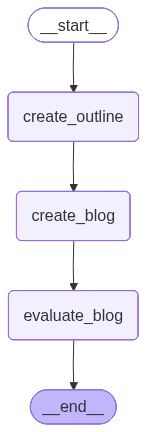

In [29]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())